<a href="https://colab.research.google.com/github/vipulpurohit851-bit/Ecommerce-Sales-Analysis/blob/main/Banking_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
customers = pd.read_csv('customers.csv')

In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  11162 non-null  int64 
 1   age          11162 non-null  int64 
 2   job          11162 non-null  object
 3   marital      11162 non-null  object
 4   education    11162 non-null  object
 5   income       11162 non-null  object
 6   card_type    11162 non-null  object
 7   branch_id    11162 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 697.8+ KB


In [ ]:
customers['income']

,income
0,$120K +
1,Less than $40K
2,$60K - $80K
3,$60K - $80K
4,$40K - $60K
...,...
11157,$120K +
11158,$40K - $60K
11159,$60K - $80K
11160,Less than $40K


In [ ]:
customers.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
11157,False
11158,False
11159,False
11160,False


In [ ]:
customers.isnull().sum()

,0
customer_id,0
age,0
job,0
marital,0
education,0
income,0
card_type,0
branch_id,0


In [ ]:
customers.describe()

,customer_id,age,branch_id
count,11162.000000,11162.000000,11162.000000
mean,5581.500000,41.231948,5.552141
std,3222.336187,11.913369,2.880908
min,1.000000,18.000000,1.000000
25%,2791.250000,32.000000,3.000000
50%,5581.500000,39.000000,6.000000
75%,8371.750000,49.000000,8.000000
max,11162.000000,95.000000,10.000000


In [ ]:
customers.columns

Index(['customer_id', 'age', 'job', 'marital', 'education', 'income',
       'card_type', 'branch_id'],
      dtype='object')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



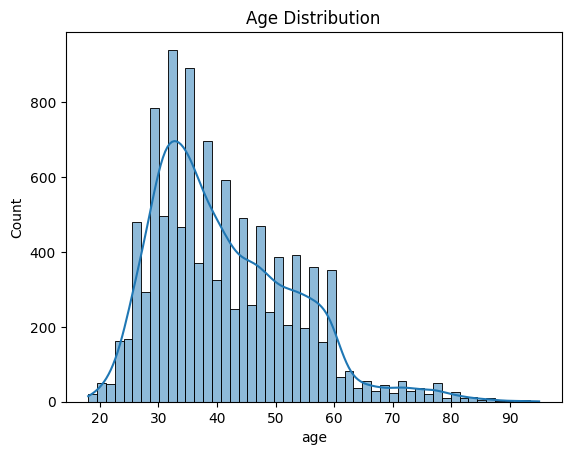

In [ ]:
# Q.1] most common age group

sns.histplot(customers['age'],kde=True)
plt.title('Age Distribution')
plt.show()



## ## Most customers are between 30–40 years, with a peak around 30–35. This suggests the bank mainly serves working professionals, making this segment highly valuable for financial products like loans and credit cards.

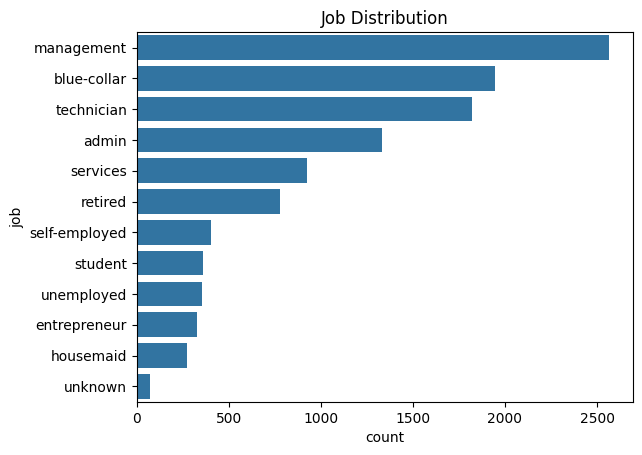

In [ ]:
# Top 3 jobs

sns.countplot(y='job', data=customers, order=customers['job'].value_counts().index)
plt.title('Job Distribution')
plt.show()

## ## Management professionals likely represent high-income customers, while blue-collar and technician segments indicate a large base of mid-income customers. This suggests the bank should offer both premium and affordable financial products.

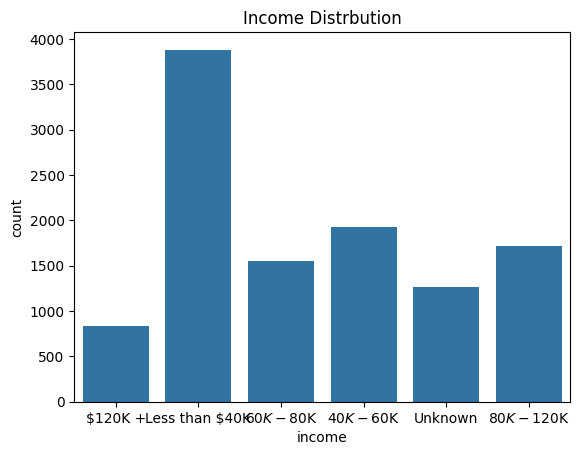

In [ ]:
# Highest income category

sns.countplot(x='income',data=customers)
plt.title('Income Distrbution')
plt.show()

## ## Most customers fall in the ‘Less than $40K’ income category, indicating a strong presence of lower-income customers. This suggests the bank should focus on providing affordable financial products. Additionally, the presence of ‘Unknown’ income values highlights potential data quality issues

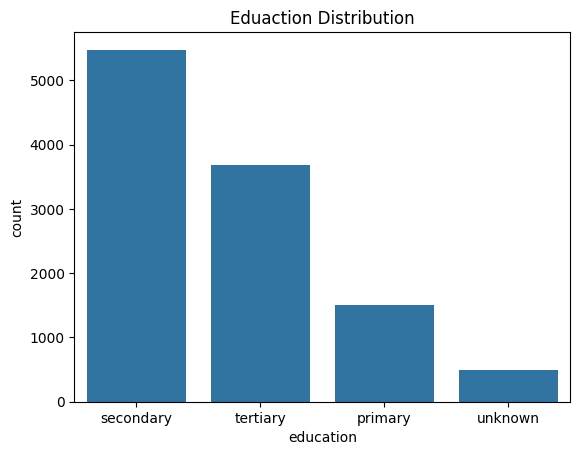

In [ ]:
# most common education level

sns.countplot(x='education',data=customers)
plt.title('Eduaction Distribution')
plt.show()

## ## Most customers have a secondary education level, indicating that the bank mainly serves individuals with mid-level education.

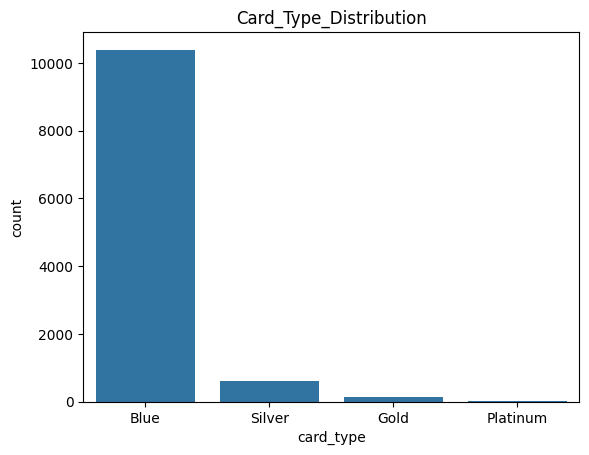

In [ ]:
# which card is most used

sns.countplot(x='card_type',data=customers)
plt.title('Card_Type_Distribution')
plt.show()


## ## Most customers use Blue cards, indicating a large base of basic users. The bank can upsell premium cards to increase revenue.

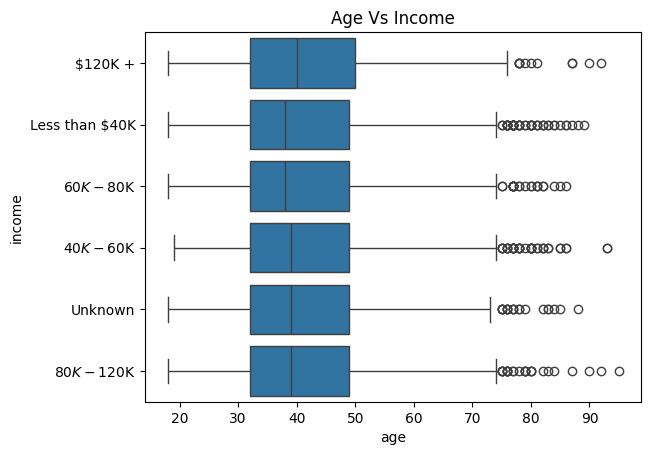

In [ ]:
sns.boxplot(x='age',y='income',data=customers)
plt.title("Age Vs Income")
plt.show()

## ## The box plot shows that most customers fall between 30–50 years across all income groups, with a median around 40. There are some higher-age outliers, indicating a small number of older customers.

In [ ]:
accounts = pd.read_csv('accounts.csv')

In [ ]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   account_id      11162 non-null  int64         
 1   customer_id     11162 non-null  int64         
 2   balance         11162 non-null  int64         
 3   account_type    11162 non-null  object        
 4   account_status  11162 non-null  object        
 5   open_date       11162 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 523.3+ KB


In [ ]:
accounts['open_date'] = pd.to_datetime(accounts['open_date'])

In [ ]:
accounts.duplicated().sum()

np.int64(0)

In [ ]:
accounts.isnull().sum()

,0
account_id,0
customer_id,0
balance,0
account_type,0
account_status,0
open_date,0


<Axes: xlabel='balance', ylabel='Count'>

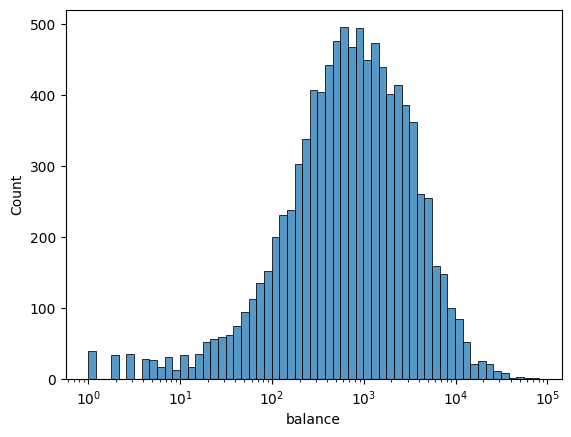

In [ ]:
sns.histplot(accounts['balance'], log_scale=True)

<Axes: xlabel='balance'>

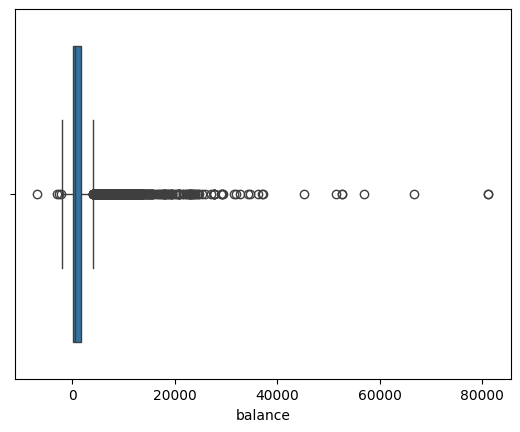

In [ ]:
sns.boxplot(x=accounts['balance'])

## ## Account balances are highly skewed with most customers having low balances, while a small number of customers hold significantly higher balances. Log transformation reveals a more normal distribution.

In [ ]:
accounts['balance'].min()


-6847

In [ ]:
accounts['balance'].max()

81204

In [ ]:
accounts['balance'].mean()

np.float64(1528.5385235620856)

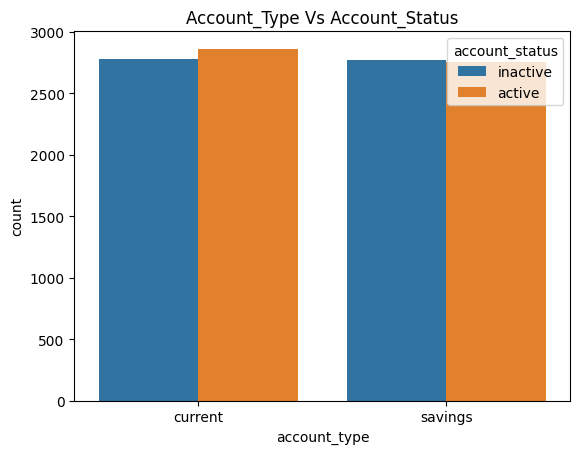

In [ ]:
sns.countplot(x='account_type',hue='account_status',data=accounts)
plt.title("Account_Type Vs Account_Status")
plt.show()

In [ ]:
transactions = pd.read_csv('transactions.csv')

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 12 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   transaction_id    1296675 non-null  int64         
 1   customer_id       1296675 non-null  int64         
 2   amount            1296675 non-null  float64       
 3   date              1296675 non-null  datetime64[ns]
 4   merchant          1296675 non-null  object        
 5   is_fraud          1296675 non-null  int64         
 6   transaction_type  1296675 non-null  object        
 7   year              1296675 non-null  int64         
 8   month             1296675 non-null  int64         
 9   day               1296675 non-null  int64         
 10  category          1296675 non-null  object        
 11  date_only         1296675 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(6), object(3)
memory usage: 118.7+ MB


In [ ]:
transactions['date'] = pd.to_datetime(transactions['date'])

In [ ]:
transactions['date_only'] = pd.to_datetime(transactions['date_only'])

In [ ]:
transactions.isnull().sum()

,0
transaction_id,0
customer_id,0
amount,0
date,0
merchant,0
is_fraud,0
transaction_type,0
year,0
month,0
day,0


In [ ]:
transactions.columns

Index(['transaction_id', 'customer_id', 'amount', 'date', 'merchant',
       'is_fraud', 'transaction_type', 'year', 'month', 'day', 'category',
       'date_only'],
      dtype='object')

In [ ]:
transactions.duplicated().sum()

np.int64(0)

In [ ]:
transactions['amount'].count()

np.int64(1296675)

In [ ]:
transactions['amount'].sum()

np.float64(91222428.9)

In [ ]:
transactions['amount'].mean()

np.float64(70.35103545607033)

In [ ]:
transactions['is_fraud'].value_counts()

,count
is_fraud,
0,1289169
1,7506


## ## Although fraud cases are rare, they can result in significant financial loss, so the bank should implement strong fraud detection systems, especially for high-risk transactions.

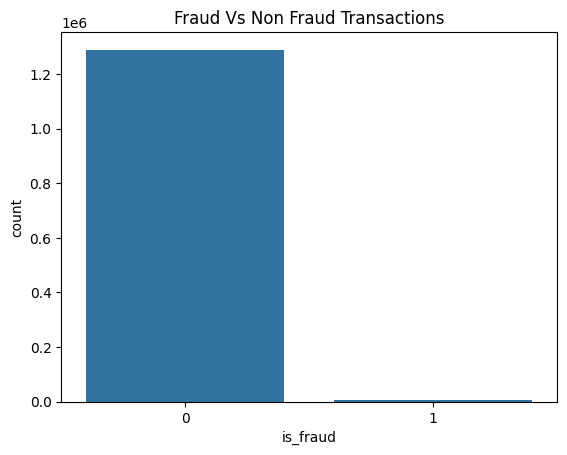

In [ ]:
sns.countplot(x='is_fraud' ,data=transactions)
plt.title("Fraud Vs Non Fraud Transactions")
plt.show()

## ## Even though fraud cases are rare, they pose significant financial risk, so the bank must prioritize fraud detection and monitoring systems

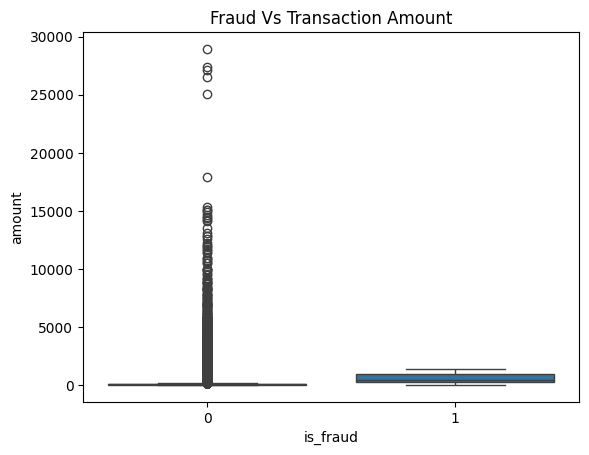

In [ ]:
sns.boxplot(x='is_fraud',y='amount',data=transactions)
plt.title("Fraud Vs Transaction Amount")
plt.show()

Fraud transactions are generally associated with higher amounts, indicating higher risk in large transactions. However, since some high-value transactions are legitimate, multiple factors are needed for accurate fraud detection

In [ ]:
transactions.groupby('is_fraud')['amount'].median()

,amount
is_fraud,
0,47.280
1,396.505


## ##Fraud transactions have a much higher median amount (396) compared to normal transactions (47), indicating that higher-value transactions carry greater fraud risk.

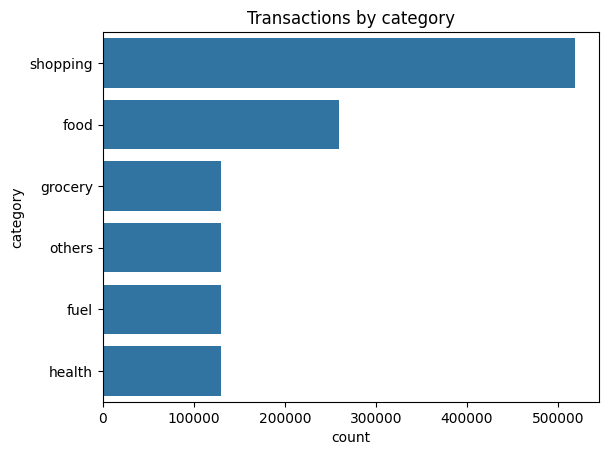

In [ ]:
# which category is highest

sns.countplot(y='category',data=transactions,order=transactions['category'].value_counts().index)
plt.title('Transactions by category')
plt.show()

## ## Shopping is the dominant transaction category, followed by food, showing that customer spending is concentrated in daily consumption areas.

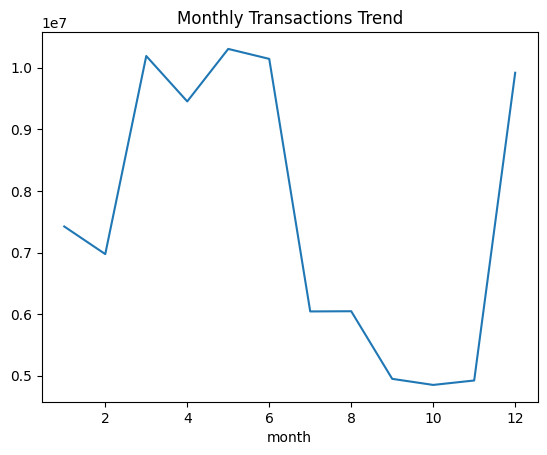

In [ ]:
transactions.groupby('month')['amount'].sum().plot()
plt.title('Monthly Transactions Trend')
plt.show()

## ##Transaction volume peaks around months 3–6 and 12, while it drops significantly between months 7–10.Transactions show seasonal trends with peaks in early and end-of-year months, suggesting higher spending during festive or promotional periods.

In [ ]:
loans = pd.read_csv('loans.csv')

In [ ]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             11162 non-null  int64  
 1   customer_id         11162 non-null  int64  
 2   loan_status         11162 non-null  object 
 3   housing_loan        11162 non-null  object 
 4   personal_loan       11162 non-null  object 
 5   loan_amount         11162 non-null  int64  
 6   loan_type           11162 non-null  object 
 7   interest_rate       11162 non-null  float64
 8   housing_loan_flag   11162 non-null  int64  
 9   personal_loan_flag  11162 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 872.2+ KB


In [ ]:
loans.head()

,loan_id,customer_id,loan_status,housing_loan,personal_loan,loan_amount,loan_type,interest_rate,housing_loan_flag,personal_loan_flag
0,1,1,rejected,yes,no,8094,home,12.87,1,0
1,2,2,approved,no,no,24870,home,9.03,0,0
2,3,3,approved,yes,no,23314,personal,14.30,1,0
3,4,4,rejected,yes,no,8159,personal,13.25,1,0
4,5,5,rejected,no,no,3510,home,11.04,0,0


In [ ]:
loans.describe()

,loan_id,customer_id,loan_amount,interest_rate,housing_loan_flag,personal_loan_flag
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,5581.500000,5581.500000,25620.830765,9.956961,0.473123,0.130801
std,3222.336187,3222.336187,14140.353420,2.893369,0.499299,0.337198
min,1.000000,1.000000,1002.000000,5.000000,0.000000,0.000000
25%,2791.250000,2791.250000,13368.250000,7.452500,0.000000,0.000000
50%,5581.500000,5581.500000,25703.000000,9.880000,0.000000,0.000000
75%,8371.750000,8371.750000,37860.500000,12.480000,1.000000,0.000000
max,11162.000000,11162.000000,49996.000000,15.000000,1.000000,1.000000


In [ ]:
loans.duplicated().sum()

np.int64(0)

In [ ]:
loans.isnull().sum()

,0
loan_id,0
customer_id,0
loan_status,0
housing_loan,0
personal_loan,0
loan_amount,0
loan_type,0
interest_rate,0
housing_loan_flag,0
personal_loan_flag,0


In [ ]:
## Which loan is more common?

loans[['housing_loan_flag','personal_loan_flag']].sum()

,0
housing_loan_flag,5281
personal_loan_flag,1460


## ## Housing loans are far more common than personal loans, indicating strong demand for long-term financing among customers.

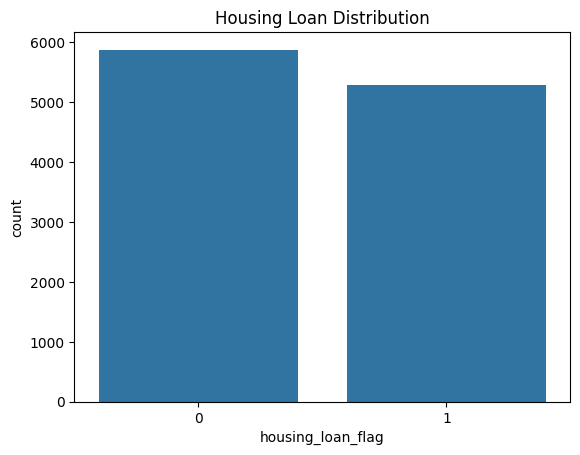

In [ ]:
## Loan Distribution

sns.countplot(x='housing_loan_flag', data=loans)
plt.title('Housing Loan Distribution')
plt.show()

## ## While housing loans are common, slightly more customers do not have them, indicating an opportunity for the bank to expand its housing loan customer base.

<Axes: xlabel='income', ylabel='count'>

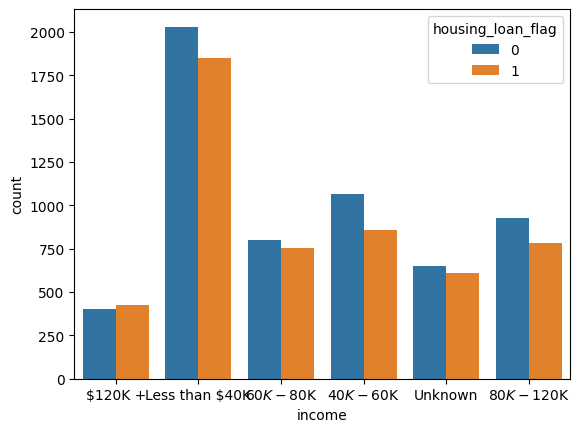

In [ ]:
## Which income group takes more loans?

df = loans.merge(customers, on='customer_id')

sns.countplot(x='income', hue='housing_loan_flag', data=df)

## ## Loan distribution is relatively consistent across income groups, with no strong dependency of loan adoption on income level.

In [ ]:
customers['branch_id'].value_counts()

,count
branch_id,
7,1183
10,1152
9,1146
5,1143
8,1131
2,1101
3,1101
1,1098
4,1075


## ## Customer distribution across branches is fairly balanced, with branch 7 having the highest number of customers.

In [ ]:
df = transactions.merge(customers, on='customer_id')

df['branch_id'].value_counts()

,count
branch_id,
7,137491
9,133510
10,133328
5,132607
8,131350
3,128460
2,128247
1,127664
4,124780


## ## Branch 7 is the top-performing branch with the highest number of customers and transactions, while other branches show relatively balanced performance with slight variations.

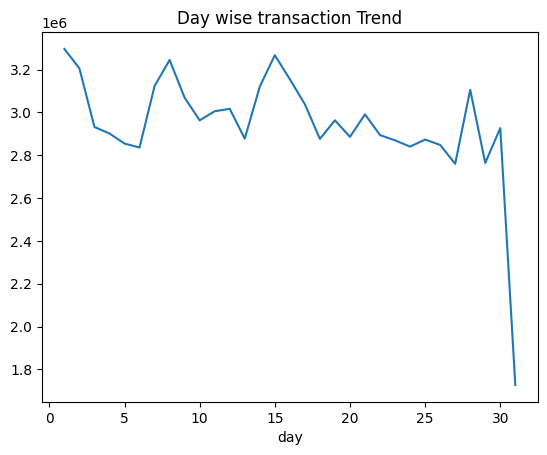

In [ ]:
transactions.groupby('day')['amount'].sum().plot()
plt.title("Day wise transaction Trend")
plt.show()

<Axes: xlabel='year'>

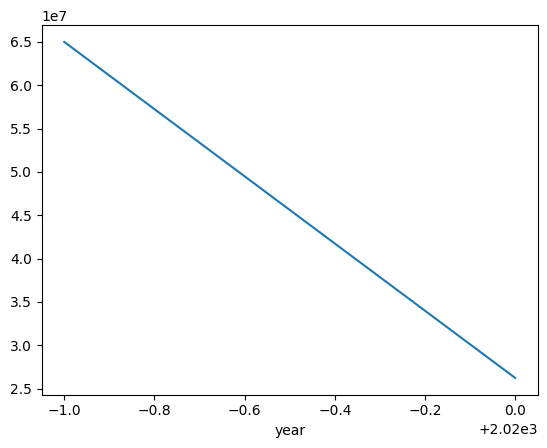

In [ ]:
transactions.groupby('year')['amount'].sum().plot()